In [110]:
import pandas as pd


events_df = pd.read_csv("./events.csv", index_col=0)
sessions_df = pd.read_csv("./sessions.csv", index_col=0)

events_df["message_obj"] = None
events_df.loc[~pd.isna(events_df["data.message"]), "message_obj"] = events_df.loc[
    ~pd.isna(events_df["data.message"])
].apply(lambda row: {"role": row.source, "content": row["data.message"]}, axis=1)


/tmp/ipykernel_23049/1193141222.py:4: DtypeWarning: Columns (23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  events_df = pd.read_csv("./events.csv", index_col=0)


In [111]:
events_df

,id,source,kind,offset,creation_utc,trace_id,correlation_id,deleted,session_id,data.message,...,data.data.matched_journeys,data.data.matched_journey_states,data.tool_calls,data.draft,data.canned_responses,data.data.exception,data.documents,data.source_name,metadata.relevant,message_obj
0,n5zDS21auw,customer,message,0,2026-05-29 11:39:12.907997+00:00,0e460eb70afc498b87f1b71d6be32221,0e460eb70afc498b87f1b71d6be32221,False,4wRCpcSuRO,Hello,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'role': 'customer', 'content': 'Hello'}"
1,mj1eytZ9Vl,ai_agent,status,1,2026-05-29 11:39:12.936253+00:00,0e460eb70afc498b87f1b71d6be32221,0e460eb70afc498b87f1b71d6be32221,False,4wRCpcSuRO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,xH2sZqcRt5,ai_agent,status,2,2026-05-29 11:39:12.952110+00:00,0e460eb70afc498b87f1b71d6be32221,0e460eb70afc498b87f1b71d6be32221,False,4wRCpcSuRO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,0l5hOdfqgC,customer,message,0,2026-06-10 10:41:07.886939+00:00,5297841b5cb5415c9b647c716b30b43a,5297841b5cb5415c9b647c716b30b43a,False,hgxsoXaan3,hejka,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'role': 'customer', 'content': 'hejka'}"
4,kfvwAwsWcY,ai_agent,status,1,2026-06-10 10:41:07.907241+00:00,5297841b5cb5415c9b647c716b30b43a,5297841b5cb5415c9b647c716b30b43a,False,hgxsoXaan3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112492,WIhB7P7qGf,ai_agent,status,17,2026-07-22 10:14:58.742121+00:00,15f0f50275604463b19a3d0662ea60d5,15f0f50275604463b19a3d0662ea60d5,False,IUWmKU6Uyp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
112493,jtWtrWvfWV,ai_agent,status,18,2026-07-22 10:15:00.575514+00:00,15f0f50275604463b19a3d0662ea60d5,15f0f50275604463b19a3d0662ea60d5,False,IUWmKU6Uyp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
112494,saZAR61ZTM,ai_agent,message,19,2026-07-22 10:15:03.555330+00:00,15f0f50275604463b19a3d0662ea60d5,15f0f50275604463b19a3d0662ea60d5,False,IUWmKU6Uyp,Na podstawie dokumentów znalazłem następujące ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'role': 'ai_agent', 'content': 'Na podstawie ..."
112495,mKrNjIWbm1,ai_agent,status,20,2026-07-22 10:15:03.562815+00:00,15f0f50275604463b19a3d0662ea60d5,15f0f50275604463b19a3d0662ea60d5,False,IUWmKU6Uyp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [112]:
conversations_df = (
    events_df.sort_values(["session_id", "offset"])
    .groupby("session_id", as_index=False)
    .agg(concatenated_message=("message_obj", lambda s: s.dropna().to_list()))
)

conversations_df

,session_id,concatenated_message
0,007oQlUhCs,"[{'role': 'customer', 'content': 'Jak zagłosow..."
1,00DGwIc9nF,"[{'role': 'customer', 'content': 'żłobek'}, {'..."
2,02H14o2oca,"[{'role': 'customer', 'content': 'Chciałabym d..."
3,02M6uQXC6E,"[{'role': 'customer', 'content': 'Planujemy po..."
4,034Y8K8wRL,"[{'role': 'customer', 'content': 'Dzień dobry...."
...,...,...
3477,zu7sDuw6mX,"[{'role': 'customer', 'content': 'Дайте відпов..."
3478,zv2DkCrGwE,"[{'role': 'customer', 'content': 'chciałbym si..."
3479,zxKHsanWml,"[{'role': 'customer', 'content': 'Dzień dobry,..."
3480,zyHKJaK7Mu,"[{'role': 'customer', 'content': 'Dzień dobry,..."


In [113]:
conversations_df["num_messages"] = conversations_df["concatenated_message"].apply(len)
conversations_df

,session_id,concatenated_message,num_messages
0,007oQlUhCs,"[{'role': 'customer', 'content': 'Jak zagłosow...",3
1,00DGwIc9nF,"[{'role': 'customer', 'content': 'żłobek'}, {'...",10
2,02H14o2oca,"[{'role': 'customer', 'content': 'Chciałabym d...",9
3,02M6uQXC6E,"[{'role': 'customer', 'content': 'Planujemy po...",6
4,034Y8K8wRL,"[{'role': 'customer', 'content': 'Dzień dobry....",11
...,...,...,...
3477,zu7sDuw6mX,"[{'role': 'customer', 'content': 'Дайте відпов...",3
3478,zv2DkCrGwE,"[{'role': 'customer', 'content': 'chciałbym si...",6
3479,zxKHsanWml,"[{'role': 'customer', 'content': 'Dzień dobry,...",11
3480,zyHKJaK7Mu,"[{'role': 'customer', 'content': 'Dzień dobry,...",14


In [114]:
def get_reformulation_indexes(messages_list):
    return [
        i
        for i, message in enumerate(messages_list)
        if "Znalezione dokumenty dla zapytania:" in message["content"]
    ]


conversations_df["reformulation_indexes"] = conversations_df[
    "concatenated_message"
].apply(get_reformulation_indexes)

conversations_df["num_reformulations"] = conversations_df[
    "reformulation_indexes"
].apply(len)

conversations_df.drop(
    index=conversations_df.query("num_reformulations == 0").index, inplace=True
)

conversations_df["num_reformulations"].value_counts()


num_reformulations
3     1124
1      811
2      714
4      580
5      156
6       23
7        1
9        1
20       1
12       1
Name: count, dtype: int64

In [115]:
conversations_df

,session_id,concatenated_message,num_messages,reformulation_indexes,num_reformulations
0,007oQlUhCs,"[{'role': 'customer', 'content': 'Jak zagłosow...",3,[1],1
1,00DGwIc9nF,"[{'role': 'customer', 'content': 'żłobek'}, {'...",10,"[3, 6]",2
2,02H14o2oca,"[{'role': 'customer', 'content': 'Chciałabym d...",9,"[1, 4, 7]",3
3,02M6uQXC6E,"[{'role': 'customer', 'content': 'Planujemy po...",6,"[1, 4]",2
4,034Y8K8wRL,"[{'role': 'customer', 'content': 'Dzień dobry....",11,"[3, 6, 9]",3
...,...,...,...,...,...
3477,zu7sDuw6mX,"[{'role': 'customer', 'content': 'Дайте відпов...",3,[1],1
3478,zv2DkCrGwE,"[{'role': 'customer', 'content': 'chciałbym si...",6,"[1, 4]",2
3479,zxKHsanWml,"[{'role': 'customer', 'content': 'Dzień dobry,...",11,"[1, 4, 7]",3
3480,zyHKJaK7Mu,"[{'role': 'customer', 'content': 'Dzień dobry,...",14,"[1, 4, 7, 10]",4


In [ ]:
from tqdm import tqdm
import random

examples = []
for idx, row in tqdm(conversations_df.iterrows(), total=len(conversations_df)):
    for reform_idx in row["reformulation_indexes"]:
        examples.append(
            {
                "history": row["concatenated_message"][: reform_idx - 1],
                "user_question": row["concatenated_message"][reform_idx - 1],
                "history_len": len(row["concatenated_message"][: reform_idx - 1]),
                "session_id": row["session_id"],
            }
        )

examples = random.sample(examples, k=1000)

examples_df = pd.DataFrame(examples)

100%|██████████| 3412/3412 [00:00<00:00, 27138.85it/s]


In [117]:
from typing import Literal

import dspy

from src.clarin_lm import create_clarin_lm


class ClassifyConversationStart(dspy.Signature):
    """
    Zaklasyfikuj pierwszą zarejestrowaną wiadomość użytkownika w rozmowie
    z asystentem pomagającym głównie w sprawach urzędowych.

    Wiadomość może być po polsku, ukraińsku albo angielsku.

    Zwróć TRUNCATED wyłącznie wtedy, gdy treść wyraźnie zależy od brakującej
    wcześniejszej części rozmowy: odwołuje się do osoby, rzeczy, dokumentu,
    wariantu, odpowiedzi, decyzji albo czynności, których nie da się
    zidentyfikować na podstawie samej wiadomości.

    Zwróć NOT_TRUNCATED, gdy wiadomość jest wystarczająco samodzielna, aby
    rozpoznać temat, problem albo intencję użytkownika — nawet jeśli:
    - jest potoczna, chaotyczna, długa lub zawiera dygresje;
    - zaczyna się od „no właśnie”, „więc”, „właściwie”, „słuchaj”, „tak”,
      „добре”, „so”, „well” lub podobnego operatora dyskursywnego;
    - zawiera zaimki lub określenia wskazujące, których znaczenie można
      ustalić z treści tej samej wiadomości;
    - nie podaje wszystkich danych potrzebnych do załatwienia sprawy;
    - użytkownik dopiero ogólnie opisuje problem albo pyta, od czego zacząć.

    Kluczowe rozróżnienie:
    - brak szczegółów, nieprecyzyjność lub niekompletna wiedza użytkownika
      NIE oznaczają ucięcia rozmowy;
    - ucięcie występuje wtedy, gdy wiadomość zakłada brakujący antecedent
      lub brakującą wcześniejszą wypowiedź, bez których istotnego odwołania
      nie da się zinterpretować.

    Nie klasyfikuj na podstawie samego zwrotu otwierającego. Oceń, czy
    nierozpoznane odwołanie jest istotne dla sensu prośby.

    Reguła rozstrzygająca: jeśli nie potrafisz wskazać konkretnego istotnego
    odwołania, którego znaczenia brakuje, wybierz NOT_TRUNCATED. Nie zgaduj,
    że przed wiadomością musiała istnieć wcześniejsza rozmowa.

    Przykłady NOT_TRUNCATED:
    - „Cześć, organizuję festiwal muzyczny i chciałabym uzyskać zezwolenie
      na czasowe zajęcie gruntu. Czy mogę złożyć wniosek? No właśnie, nie wiem
      od czego zacząć, bo mam trochę zamieszania.”
    - „Do jakiej kategorii spraw w BIP UM Wrocław należy sprawa:
      «Likwidacja klubu sportowego i uczniowskiego klubu sportowego»?”
    - „Słuchaj, chciałbym się dowiedzieć, jak mogę zgłosić projekt usuwania
      azbestu i czy jest jakaś dopłata z miasta.”
    - „Dzień dobry, zgubiłem dowód.”
    - „No właśnie, chcę zrobić imprezę masową i zastanawiam się, co muszę
      złożyć, bo mam niejasności co do dokumentów.”
    - „I lost my passport. Where should I report it?”
    - „Я загубила посвідчення особи. Що мені робити?”

    Przykłady TRUNCATED:
    - „No właśnie, zgubiłam wszystkie papierki z budowy i nie wiem, co dalej
      zrobić z tym zaświadczeniem.” — nie wiadomo, o jakie zaświadczenie chodzi.
    - „Tak, chodzi mi o ten drugi wniosek. Gdzie mam go złożyć?” — brak informacji,
      jakie wnioski były wcześniej omawiane.
    - „And what documents do I need for it?” — nie wiadomo, czego dotyczy „it”.
    - „А куди його подати?” — nie wiadomo, co ma zostać złożone.

    Zwróć dokładnie jedną z dwóch etykiet:
    - TRUNCATED
    - NOT_TRUNCATED
    """

    first_user_message: str = dspy.InputField(
        desc=(
            "Pierwsza zarejestrowana wiadomość użytkownika; może być po polsku, "
            "ukraińsku albo angielsku."
        )
    )

    classification: Literal["TRUNCATED", "NOT_TRUNCATED"] = dspy.OutputField(
        desc=(
            "Dokładnie TRUNCATED, jeżeli wiadomość wymaga brakującego wcześniejszego "
            "kontekstu; w przeciwnym razie dokładnie NOT_TRUNCATED."
        )
    )


module = dspy.Predict(ClassifyConversationStart)


exec_pairs = [
    (module, {"first_user_message": item["user_question"]["content"]})
    for idx, item in examples_df.iterrows()
]

dspy.configure(lm=create_clarin_lm("gemma-3-4b-it"))

parallel = dspy.Parallel(num_threads=10, disable_progress_bar=False)


In [118]:
examples_df

,history,user_question,history_len,session_id
0,"[{'role': 'customer', 'content': 'Dzień dobry,...","{'role': 'customer', 'content': 'To proszę o i...",9,QxDWYwYjdr
1,"[{'role': 'customer', 'content': 'Dzień dobry,...","{'role': 'customer', 'content': 'A ile dokładn...",3,IQIcf1wkDC
2,"[{'role': 'customer', 'content': 'Dzień dobry....","{'role': 'customer', 'content': 'Chciałabym uz...",2,27rjl0nwnB
3,[],"{'role': 'customer', 'content': 'Chcę zaświadc...",0,gpnbsWAluF
4,"[{'role': 'customer', 'content': 'Dzień dobry....","{'role': 'customer', 'content': 'Chcę zrobić r...",2,n3FcXVGIIp
...,...,...,...,...
995,"[{'role': 'customer', 'content': 'Chcę się dow...","{'role': 'customer', 'content': 'A jakie dokum...",3,ySseGLrPUl
996,[],"{'role': 'customer', 'content': 'Dzień dobry, ...",0,JckN6jAFQU
997,"[{'role': 'customer', 'content': 'Cześć, czyli...","{'role': 'customer', 'content': 'Tak, poproszę...",3,ThGPRcCKJ7
998,[],"{'role': 'customer', 'content': 'Dzień dobry. ...",0,cILJ61qvnG


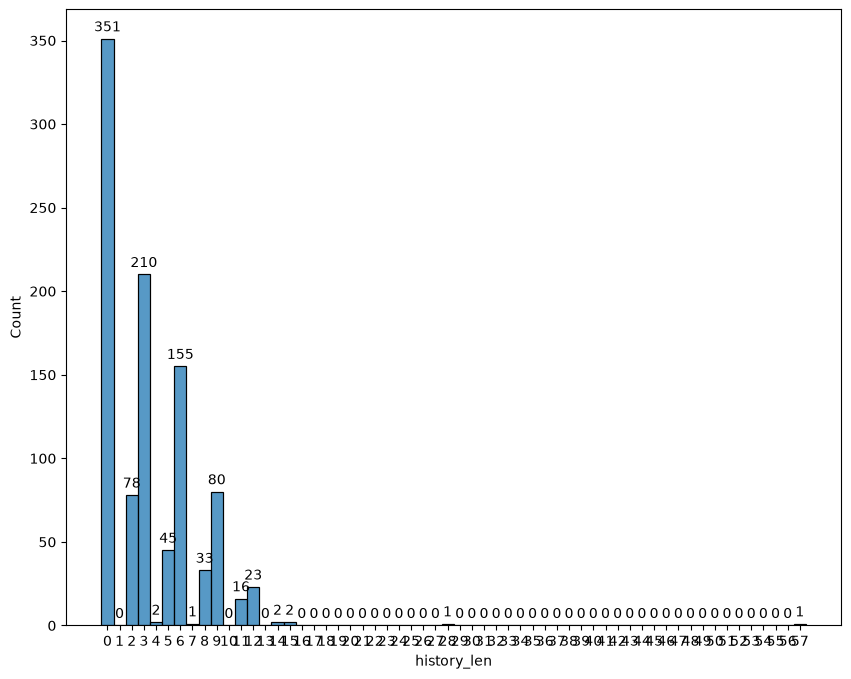

In [119]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns


def draw_histplot(series):
    fig = plt.figure(figsize=(10, 8))
    max_x = np.max(series)
    ax = sns.histplot(
        series,
        element="bars",
        bins=np.arange(-0.5, max_x + 1.5, 1),
    )
    ax.set_xticks(range(max_x + 1))
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=lambda value: str(int(value)),
            padding=3,
        )


draw_histplot(examples_df["history_len"])

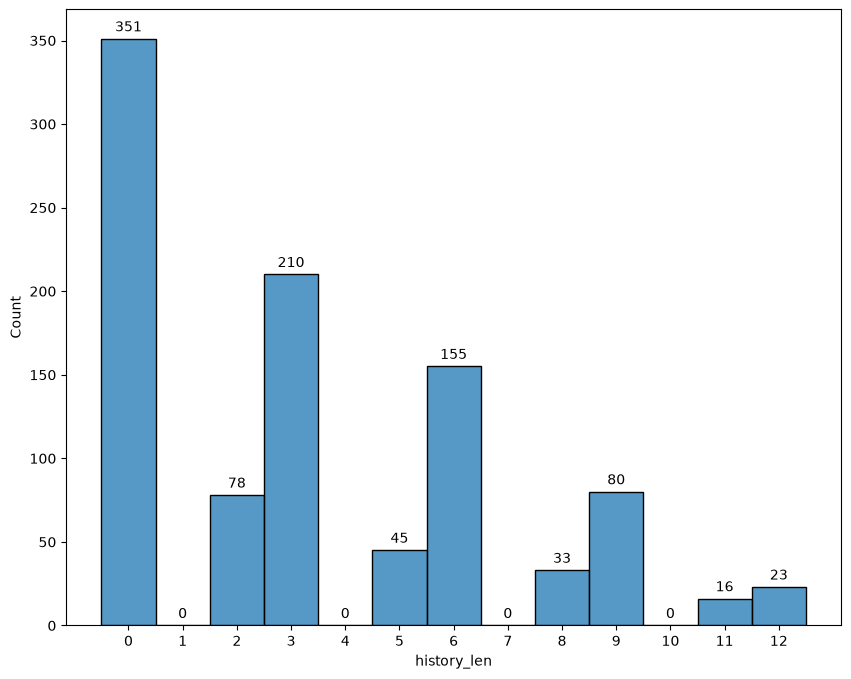

In [120]:
draw_histplot(
    examples_df.groupby(by="history_len").filter(lambda x: len(x) > 10)["history_len"]
)

In [121]:
examples_df

,history,user_question,history_len,session_id
0,"[{'role': 'customer', 'content': 'Dzień dobry,...","{'role': 'customer', 'content': 'To proszę o i...",9,QxDWYwYjdr
1,"[{'role': 'customer', 'content': 'Dzień dobry,...","{'role': 'customer', 'content': 'A ile dokładn...",3,IQIcf1wkDC
2,"[{'role': 'customer', 'content': 'Dzień dobry....","{'role': 'customer', 'content': 'Chciałabym uz...",2,27rjl0nwnB
3,[],"{'role': 'customer', 'content': 'Chcę zaświadc...",0,gpnbsWAluF
4,"[{'role': 'customer', 'content': 'Dzień dobry....","{'role': 'customer', 'content': 'Chcę zrobić r...",2,n3FcXVGIIp
...,...,...,...,...
995,"[{'role': 'customer', 'content': 'Chcę się dow...","{'role': 'customer', 'content': 'A jakie dokum...",3,ySseGLrPUl
996,[],"{'role': 'customer', 'content': 'Dzień dobry, ...",0,JckN6jAFQU
997,"[{'role': 'customer', 'content': 'Cześć, czyli...","{'role': 'customer', 'content': 'Tak, poproszę...",3,ThGPRcCKJ7
998,[],"{'role': 'customer', 'content': 'Dzień dobry. ...",0,cILJ61qvnG


In [122]:
def replace_newline(string):
    return string.replace("\n", " ")


def stringify_history(history):
    res = ""
    for message in history:
        res += f"{message['role']}:\n{replace_newline(message['content'])}\n"
    return res.strip()


examples_df.groupby(by="history_len").filter(lambda x: len(x) > 10).groupby(
    by="history_len"
).sample(n=10, random_state=11).assign(
    user_question=lambda df: df["user_question"].apply(lambda q: q["content"])
).assign(history=lambda df: df["history"].apply(stringify_history)).to_clipboard()

In [125]:
examples_df.groupby(by="history_len").filter(lambda x: len(x) > 10).groupby(
    by="history_len"
).sample(n=10, random_state=11).assign(
    user_question=lambda df: df["user_question"].apply(lambda q: q["content"])
).assign(history=lambda df: df["history"].apply(stringify_history))


,history,user_question,history_len,session_id
269,,Dzień dobry. Chciałabym uzyskać jednorazową po...,0,C90tSUbFW5
764,,Дайте відповідь на запитання українською мовою...,0,dPfKXiyupD
830,,Chciałabym złożyć wniosek o zmianę decyzji. Co...,0,ZElg3zTPW1
44,,"Dzień dobry, właśnie wróciłem z urzędu, trochę...",0,dLUJ5Gow9T
539,,"Dzień dobry, chciałbym złożyć wniosek o opinię...",0,dFtpuUgDfY
...,...,...,...,...
121,"customer:\nNadchodzi ten ważny moment, w który...",W jakich szkołach we Wrocławiu są takie oddziały?,12,tfRXYnS7SR
112,customer:\nPotrzebuję zezwolenia na wjazd cięż...,Jaki jest termin złożenia wniosku?,12,4jS86IKbIu
275,customer:\ndzien dobry. potrzebuje ustalić war...,"Dobrze, chciałabym jeszcze wiedzieć, czy potrz...",12,EEcMdv6GN7
217,"customer:\nZgubiłam się w papierach, mam już d...",Czy mogę to zrobić listownie czy muszę przyjść...,12,dnYbagTPlf


In [123]:
df_annotated = pd.read_clipboard()

In [136]:
subsample_df = (
    examples_df.groupby(by="history_len")
    .filter(lambda x: len(x) > 10)
    .groupby(by="history_len")
    .sample(n=10, random_state=11)
    .assign(user_question=lambda df: df["user_question"].apply(lambda q: q["content"]))
)

In [137]:
subsample_df["reformulated question"] = df_annotated["reformulated question"]
subsample_df["flagged"] = df_annotated["flagged"]

In [141]:
subsample_df[subsample_df["flagged"].isna()].to_json(
    lines=True, path_or_buf="./convos.jsonl", orient="records", force_ascii=False
)